In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import csv

In [2]:
data = [
    ["date","product","category","price","quantity","city"],
    ["2024-01-01","Laptop","Electronics",60000,2,"Mumbai"],
    ["2024-01-02","Phone","Electronics",30000,3,"Pune"],
    ["2024-01-03","Tablet","Electronics",20000,1,"Delhi"],
    ["2024-01-04","Headphones","Accessories",2000,5,"Mumbai"],
    ["2024-01-05","Keyboard","Accessories",1500,4,"Pune"],
    ["2024-01-06","Mouse","Accessories",800,6,"Delhi"],
    ["2024-01-07","Laptop","Electronics",62000,1,"Mumbai"],
    ["2024-01-08","Phone","Electronics",28000,2,"Pune"],
    ["2024-01-09","Tablet","Electronics",21000,3,"Delhi"],
    ["2024-01-10","Headphones","Accessories",2200,2,"Mumbai"],
    ["2024-01-11","Keyboard","Accessories",1700,3,"Pune"],
    ["2024-01-12","Mouse","Accessories",900,5,"Delhi"],
    ["2024-01-13","Laptop","Electronics",61000,2,"Mumbai"],
    ["2024-01-14","Phone","Electronics",29000,2,"Pune"],
    ["2024-01-15","Tablet","Electronics",20500,1,"Delhi"],
    ["2024-01-16","Headphones","Accessories",2100,4,"Mumbai"],
    ["2024-01-17","Keyboard","Accessories",1600,2,"Pune"],
    ["2024-01-18","Mouse","Accessories",850,3,"Delhi"],
    ["2024-01-19","Laptop","Electronics",63000,1,"Mumbai"],
    ["2024-01-20","Phone","Electronics",31000,2,"Pune"]
]

with open("sales_data.csv","w",newline="") as file:
    writer = csv.writer(file)
    writer.writerows(data)

print("Dataset file created successfully!")

Dataset file created successfully!


In [4]:
df = pd.read_csv("sales_data.csv")

print("\nFirst 5 rows of dataset")
print(df.head())

print("\nInformation about dataset")
print(df.info())


First 5 rows of dataset
         date     product     category  price  quantity    city
0  2024-01-01      Laptop  Electronics  60000         2  Mumbai
1  2024-01-02       Phone  Electronics  30000         3    Pune
2  2024-01-03      Tablet  Electronics  20000         1   Delhi
3  2024-01-04  Headphones  Accessories   2000         5  Mumbai
4  2024-01-05    Keyboard  Accessories   1500         4    Pune

Information about dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      20 non-null     object
 1   product   20 non-null     object
 2   category  20 non-null     object
 3   price     20 non-null     int64 
 4   quantity  20 non-null     int64 
 5   city      20 non-null     object
dtypes: int64(2), object(4)
memory usage: 1.1+ KB
None


In [5]:
df["date"] = pd.to_datetime(df["date"])
df["revenue"] = df["price"] * df["quantity"]

print("\nDataset after adding revenue column")
print(df.head())


Dataset after adding revenue column
        date     product     category  price  quantity    city  revenue
0 2024-01-01      Laptop  Electronics  60000         2  Mumbai   120000
1 2024-01-02       Phone  Electronics  30000         3    Pune    90000
2 2024-01-03      Tablet  Electronics  20000         1   Delhi    20000
3 2024-01-04  Headphones  Accessories   2000         5  Mumbai    10000
4 2024-01-05    Keyboard  Accessories   1500         4    Pune     6000


In [6]:
total_revenue = df["revenue"].sum()
average_revenue = df["revenue"].mean()
median_revenue = df["revenue"].median()

print("\nTotal Revenue:", total_revenue)
print("Average Revenue:", average_revenue)
print("Median Revenue:", median_revenue)


Total Revenue: 785450
Average Revenue: 39272.5
Median Revenue: 20250.0


In [7]:
product_sales = df.groupby("product")["revenue"].sum()
print("\nRevenue by Product")
print(product_sales)

top_product = product_sales.idxmax()
print("\nTop Selling Product:", top_product)


Revenue by Product
product
Headphones     22800
Keyboard       14300
Laptop        367000
Mouse          11850
Phone         266000
Tablet        103500
Name: revenue, dtype: int64

Top Selling Product: Laptop


In [8]:
city_sales = df.groupby("city")["revenue"].sum()
print("\nRevenue by City")
print(city_sales)

top_city = city_sales.idxmax()
print("\nCity with Highest Revenue:", top_city)


Revenue by City
city
Delhi     115350
Mumbai    389800
Pune      280300
Name: revenue, dtype: int64

City with Highest Revenue: Mumbai


In [9]:
category_sales = df.groupby("category")["revenue"].sum()
print("\nRevenue by Category")
print(category_sales)


Revenue by Category
category
Accessories     48950
Electronics    736500
Name: revenue, dtype: int64


In [10]:
pivot_table = pd.pivot_table(
    df,
    values="revenue",
    index="city",
    columns="product",
    aggfunc="sum"
)

print("\nPivot Table")
print(pivot_table)


Pivot Table
product  Headphones  Keyboard    Laptop    Mouse     Phone    Tablet
city                                                                
Delhi           NaN       NaN       NaN  11850.0       NaN  103500.0
Mumbai      22800.0       NaN  367000.0      NaN       NaN       NaN
Pune            NaN   14300.0       NaN      NaN  266000.0       NaN


In [11]:
sorted_df = df.sort_values(by="revenue", ascending=False)
sorted_df.to_csv("sorted_sales_data.csv", index=False)
print("\nSorted dataset exported!")


Sorted dataset exported!


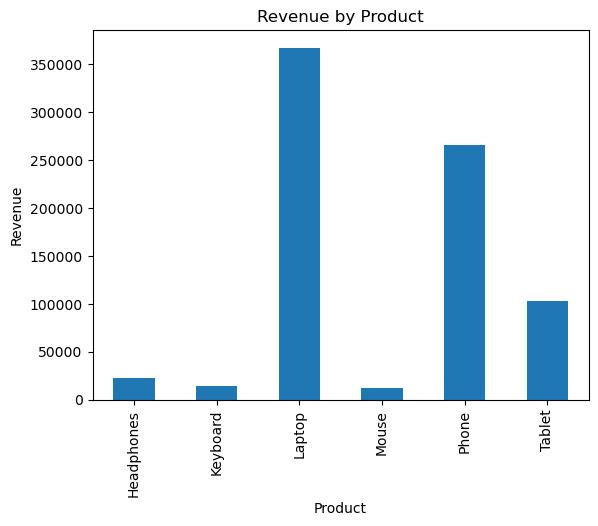

In [12]:
product_sales.plot(kind="bar")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

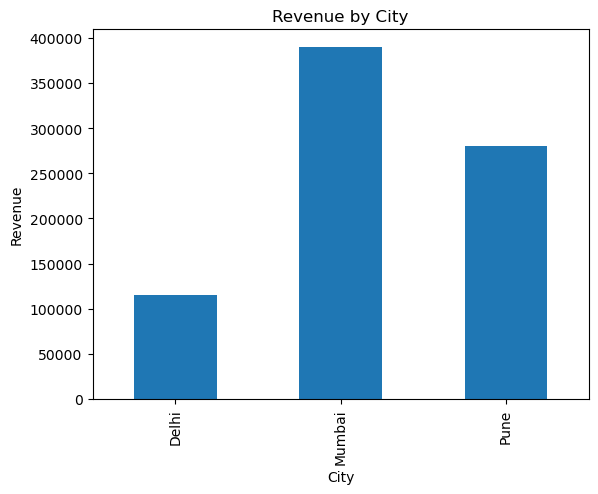

In [13]:
city_sales.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

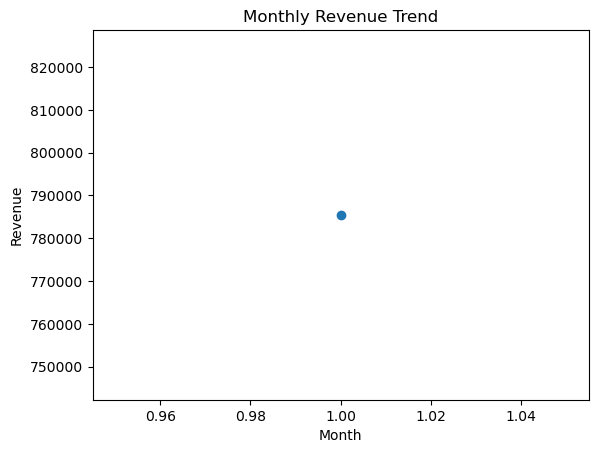

In [14]:
df["month"] = df["date"].dt.month
monthly_sales = df.groupby("month")["revenue"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [15]:
top_transactions = df.nlargest(5, "revenue")
print("\nTop 5 Highest Revenue Transactions")
print(top_transactions)


Top 5 Highest Revenue Transactions
         date product     category  price  quantity    city  revenue  month
12 2024-01-13  Laptop  Electronics  61000         2  Mumbai   122000      1
0  2024-01-01  Laptop  Electronics  60000         2  Mumbai   120000      1
1  2024-01-02   Phone  Electronics  30000         3    Pune    90000      1
8  2024-01-09  Tablet  Electronics  21000         3   Delhi    63000      1
18 2024-01-19  Laptop  Electronics  63000         1  Mumbai    63000      1


In [16]:
product_quantity = df.groupby("product")["quantity"].sum()
print("\nTotal Quantity Sold by Product")
print(product_quantity)

best_selling_product = product_quantity.idxmax()
print("\nBest Selling Product (by quantity):", best_selling_product)


Total Quantity Sold by Product
product
Headphones    11
Keyboard       9
Laptop         6
Mouse         14
Phone          9
Tablet         5
Name: quantity, dtype: int64

Best Selling Product (by quantity): Mouse


In [17]:
city_category_sales = df.groupby(["city", "category"])["revenue"].sum()
print("\nCity and Category Revenue Analysis")
print(city_category_sales)


City and Category Revenue Analysis
city    category   
Delhi   Accessories     11850
        Electronics    103500
Mumbai  Accessories     22800
        Electronics    367000
Pune    Accessories     14300
        Electronics    266000
Name: revenue, dtype: int64


In [18]:
print("\nData Analytics Project Completed Successfully!")


Data Analytics Project Completed Successfully!
